In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import datetime


from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [2]:
import kagglehub
path = kagglehub.dataset_download("sudalairajkumar/daily-temperature-of-major-cities")
print("Path to dataset files:", path)

import os
os.listdir(path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/sudalairajkumar/daily-temperature-of-major-cities/versions/1


['city_temperature.csv']

In [3]:
data = pd.read_csv(path + '/city_temperature.csv')
print(data.shape)
data.head()

/var/folders/85/6_l83d_53d13vh2zg9mlxcw40000gn/T/ipykernel_5966/1799479437.py:1: DtypeWarning: Columns (0: State) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path + '/city_temperature.csv')


(2906327, 8)


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [4]:
data = data[(data['City'] == 'San Francisco') | (data['City'] == 'Los Angeles')]

data.columns = [col.lower().replace(' ', '_') for col in data.columns]
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data = data[['city', 'date', 'avgtemperature']]
data = data[data['date'] >= '2010-01-01']

data.columns = ['unique_id', 'ds', 'y']
data = data.reset_index(drop=True)

print(data.shape)
data.head()


(7572, 3)


,unique_id,ds,y
0,Los Angeles,2010-01-01,58.0
1,Los Angeles,2010-01-02,63.9
2,Los Angeles,2010-01-03,65.6
3,Los Angeles,2010-01-04,63.9
4,Los Angeles,2010-01-05,61.5


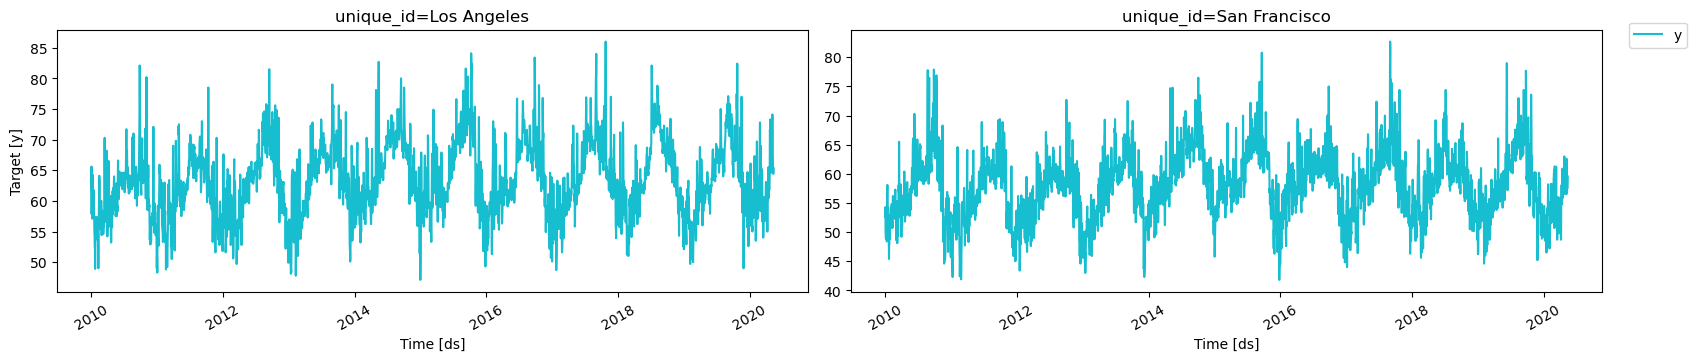

In [5]:
plot_series(df = data, ids=['Los Angeles', 'San Francisco'])

### Baseline Models

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

horizon = 90
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size = 365),
    SeasonalNaive(season_length = 365)
]

sf = StatsForecast(models = models, freq = 'D', n_jobs = -1)

In [7]:
test = data.groupby("unique_id").tail(horizon)
train = data.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds = sf.predict(h = horizon)
preds = preds.reset_index() 

/opt/anaconda3/envs/time_series_analysis/lib/python3.14/site-packages/statsforecast/core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


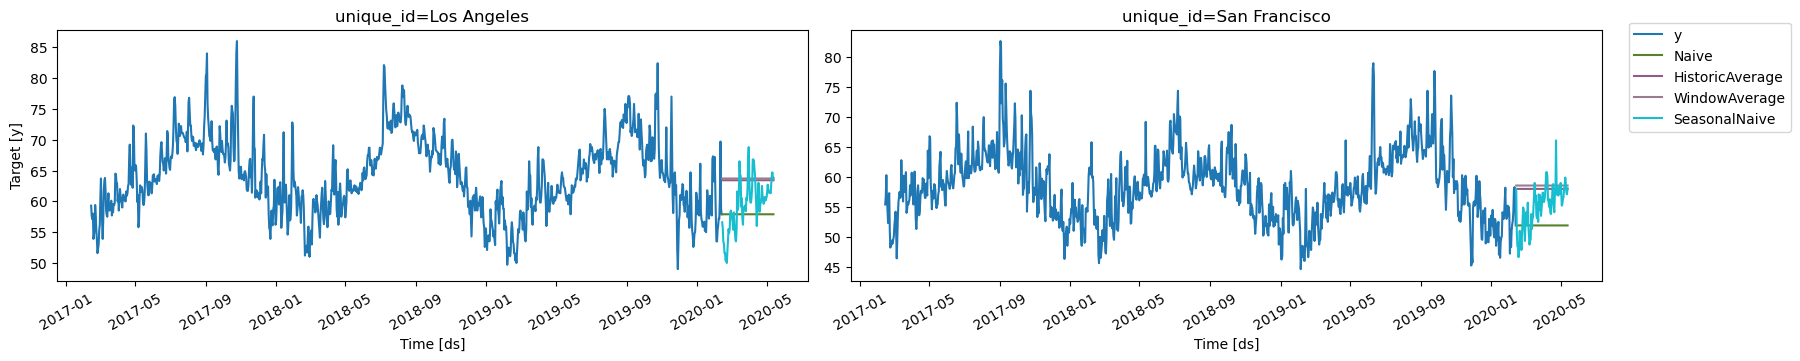

In [8]:
plot_series(
    df = train,
    forecasts_df = preds,
    ids = ['Los Angeles','San Francisco'],
    max_insample_length = 365 * 3
)

In [9]:
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Los Angeles,mae,4.844443,4.036973,4.121619,5.325556
1,San Francisco,mae,4.363332,3.248188,3.524613,3.707778


In [10]:
evaluation = evaluation.drop(['unique_id'], axis = 1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,4.603888,3.642581,3.823116,4.516667


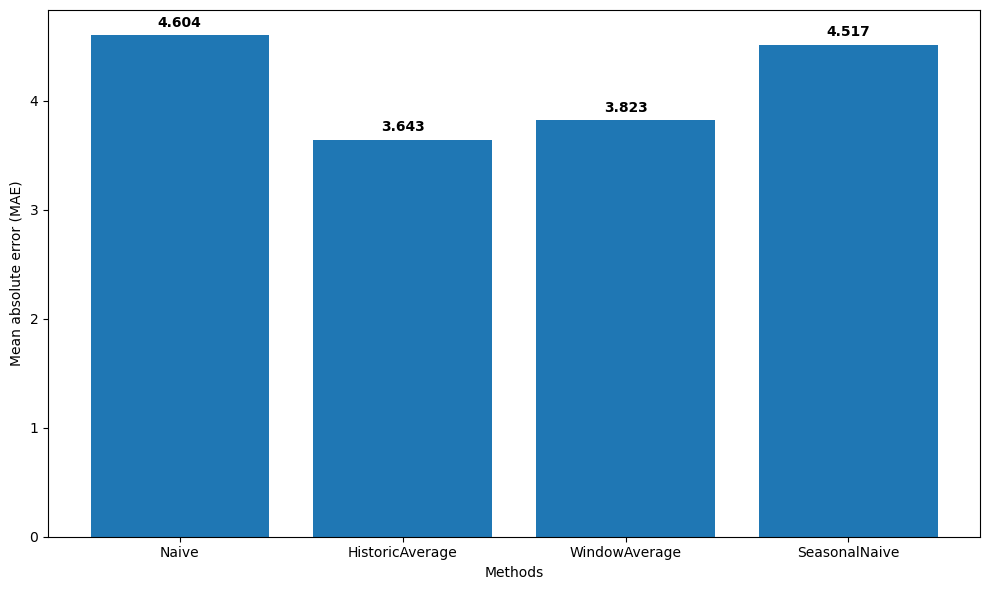

In [11]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha = 'center', va = 'bottom', fontweight = 'bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

### AutoARIMA Models

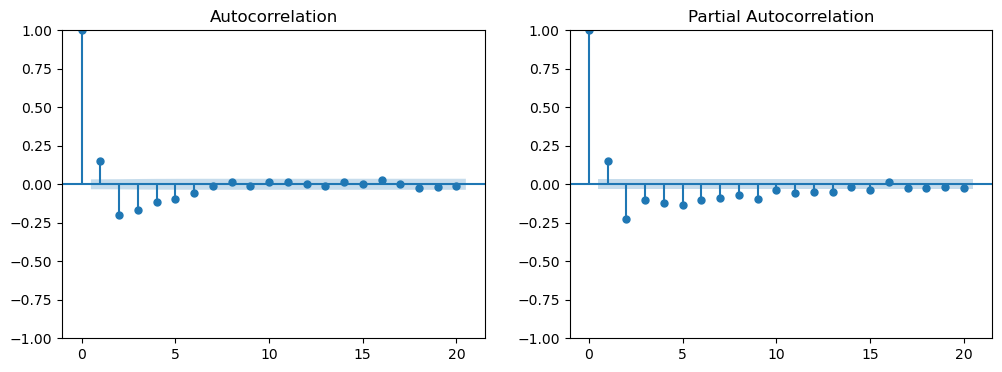

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use one city's differenced series
la = train[train['unique_id'] == 'Los Angeles']['y'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(la, lags=20, ax=axes[0])
plot_pacf(la, lags=20, ax=axes[1])
plt.show()

In [53]:
from statsforecast.models import AutoARIMA

unique_ids = ['Los Angeles', 'San Francisco']
#small_train = train[train['unique_id'].isin(unique_ids)]
#small_test = test[test['unique_id'].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, d=1, start_p=1, start_q=1, max_p=3, max_q=3, alias='ARIMA'),
    AutoARIMA(season_length=30, d=1, start_p=1, start_q=1, max_p=3, max_q=3, alias='SARIMA'),
]

sf_arima = StatsForecast(models = models, freq = 'D', n_jobs = -1)
sf_arima.fit(df = train)
arima_preds = sf_arima.predict(h = horizon)
arima_preds = arima_preds.reset_index()

/opt/anaconda3/envs/time_series_analysis/lib/python3.14/site-packages/statsforecast/core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


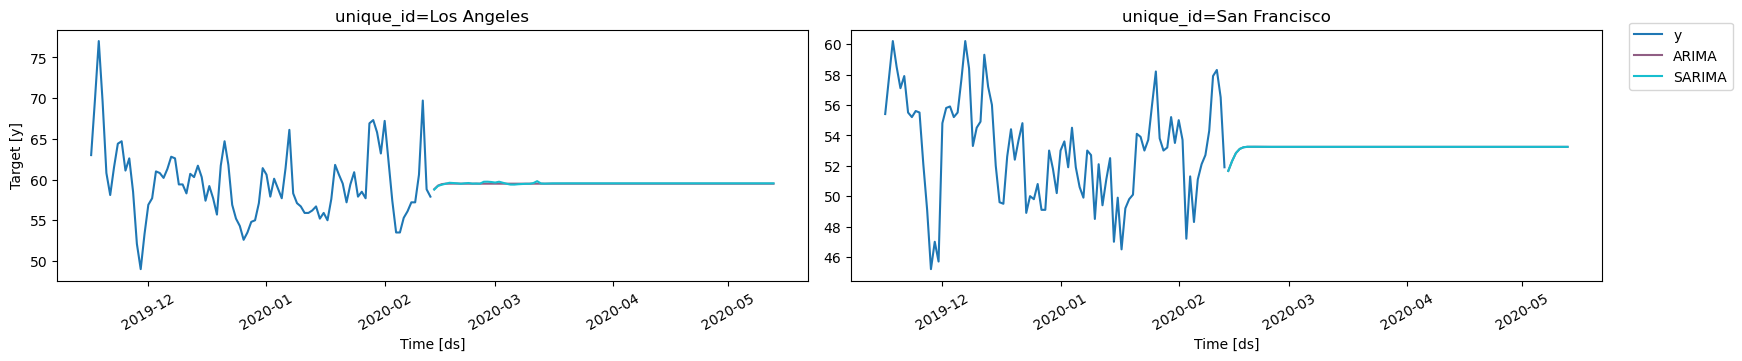

In [54]:
plot_series(
    df = train,
    forecasts_df = arima_preds,
    ids = ['Los Angeles', 'San Francisco'],
    max_insample_length = 90 
)

In [55]:
# --- Evaluate ARIMA models independently ---
arima_eval_df = pd.merge(test, arima_preds, 'left', ['ds', 'unique_id'])

arima_eval = evaluate(arima_eval_df, metrics=[mae])
arima_eval_mean = (arima_eval
    .drop('unique_id', axis=1)
    .groupby('metric')
    .mean()
    .reset_index()
)
display(arima_eval)
display(arima_eval_mean)

,unique_id,metric,ARIMA,SARIMA
0,Los Angeles,mae,3.926272,3.897541
1,San Francisco,mae,3.506246,3.506246


,metric,ARIMA,SARIMA
0,mae,3.716259,3.701894


In [56]:
# --- Combine with baseline evaluation for fair comparison ---
# Re-evaluate baselines on small_test only (same cities, same horizon)
baseline_eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])
baseline_eval = evaluate(baseline_eval_df, metrics=[mae])
baseline_eval_mean = (baseline_eval
    .drop('unique_id', axis=1)
    .groupby('metric')
    .mean()
    .reset_index()
)

# Join on metric column — clean and explicit
combined_eval = pd.merge(baseline_eval_mean, arima_eval_mean, on='metric')
combined_eval

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,ARIMA,SARIMA
0,mae,4.603888,3.642581,3.823116,4.516667,3.716259,3.701894


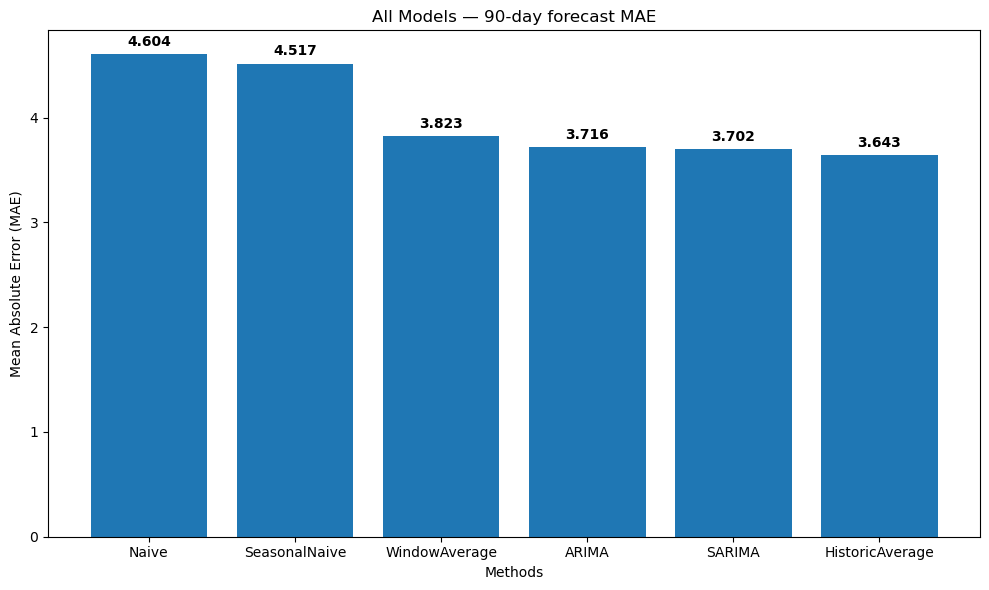

In [57]:
# --- Bar chart: all models compared ---
methods = combined_eval.columns[1:].tolist()
values  = combined_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse = True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('All Models — 90-day forecast MAE')
plt.tight_layout()
plt.show()